<a href="https://colab.research.google.com/github/rubysmac/BVC/blob/main/BVC_Apr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from huggingface_hub import login
login()

In [3]:
# # Use a pipeline as a high-level helper
# from transformers import pipeline

# pipe = pipeline("text-generation", model="meta-llama/Llama-3.1-8B-Instruct")
# messages = [
#     {"role": "user", "content": "Who are you?"},
# ]
# pipe(messages)

In [4]:
import os
save_drive = '/content/drive/MyDrive/Smith/BVC/'
#os.makedirs(save_drive, exist_ok=True) # Creates the folder if it doesn't exist


In [5]:
MODEL_NAME ="meta-llama/Llama-3.1-8B-Instruct"

In [6]:
do_sample=False

In [7]:
#!pip -q install -U transformers accelerate bitsandbytes sentencepiece

In [8]:
import json
import re
from dataclasses import dataclass
from typing import List, Tuple, Union, Dict, Any, Optional

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [9]:
# =========================
# Shape classes
# =========================

class Rect:
    def __init__(self, x, y, w, h):
        self.x = x
        self.y = y      # top-left y
        self.w = w
        self.h = h

class Circle:
    def __init__(self, cx, cy, r):
        self.cx = cx
        self.cy = cy
        self.r = r

class Triangle:
    def __init__(self, p1, p2, p3):
        self.p1 = p1
        self.p2 = p2
        self.p3 = p3

class NamedShape:
    def __init__(self, name: str, shape: Union[Rect, Circle, Triangle]):
        self.name = name
        self.shape = shape

In [10]:
def shape_to_dict(ns: NamedShape) -> Dict[str, Any]:
    s = ns.shape
    if isinstance(s, Rect):
        return {
            "name": ns.name,
            "type": "Rect",
            "properties": {
                "x": s.x,
                "y": s.y,
                "w": s.w,
                "h": s.h
            }
        }
    elif isinstance(s, Circle):
        return {
            "name": ns.name,
            "type": "Circle",
            "properties": {
                "cx": s.cx,
                "cy": s.cy,
                "r": s.r
            }
        }
    elif isinstance(s, Triangle):
        return {
            "name": ns.name,
            "type": "Triangle",
            "properties": {
                "p1": s.p1,
                "p2": s.p2,
                "p3": s.p3
            }
        }
    else:
        raise TypeError(f"Unsupported shape type: {type(s)}")


def canvas_to_jsonable(canvas: List[NamedShape]) -> List[Dict[str, Any]]:
    return [shape_to_dict(ns) for ns in canvas]


def canvas_to_pretty_json(canvas: List[NamedShape]) -> str:
    return json.dumps(canvas_to_jsonable(canvas), indent=2)

In [11]:
SYSTEM_PROMPT = """You are an Oracle for design-intent inference.
You must output valid JSON only.
Do not include markdown fences.
Do not include commentary outside the JSON.
"""

USER_PROMPT_TEMPLATE = """Return valid JSON only.

Given two canvas states:
- C1 (before)
- C2 (after one edit)

Shapes:
- Rect: x(bottom-left x), y(top-left y), w (width), h (height)
- Circle: cx, cy, r
- Triangle: p1(left point on bottom), p2(apex), p3(right point on bottom)

Tasks:
1. Find all changed object-property pairs from C1 → C2.
2. Put them in "locked_properties".
3. Infer up to 5 intents.
4. For each intent, predict next changes without modifying locked properties.

Rules:
- Use only objects and properties in input.
- Each intent modifies ONE object only.
- Multiple properties of that object may be changed.
- Do NOT modify multiple objects.
- "change" must be a list of equation strings.
- No natural language inside equations.
- Likelihood ∈ [0,1].
- Output JSON only. No extra text.

Schema:
{{
  "locked_properties": [
    {{"object": "...", "property": "..."}}
  ],
  "intents": [
    {{
      "intent": "...",
      "likelihood": 0.0,
      "next": [
        {{
          "change": ["object.property = expression"],
          "reason": "..."
        }}
      ]
    }}
  ]
}}

C1:
{c1_json}

C2:
{c2_json}
"""

In [12]:
def build_prompt(c1: List[NamedShape], c2: List[NamedShape]) -> str:
    return USER_PROMPT_TEMPLATE.format(
        c1_json=canvas_to_pretty_json(c1),
        c2_json=canvas_to_pretty_json(c2)
    )

In [13]:

def load_llama_model(model_name: str = MODEL_NAME):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        dtype=torch.bfloat16
    )
    model.eval()
    return tokenizer, model

In [14]:
def extract_first_json_object(text: str) -> str:
    """
    Extract the first top-level JSON object from model output.
    """
    start = text.find("{")
    if start == -1:
        raise ValueError("No JSON object start found.")

    depth = 0
    for i in range(start, len(text)):
        if text[i] == "{":
            depth += 1
        elif text[i] == "}":
            depth -= 1
            if depth == 0:
                return text[start:i+1]

    raise ValueError("No complete JSON object found.")


def validate_output_schema(data: Dict[str, Any]) -> Dict[str, Any]:
    if "locked_properties" not in data or "intents" not in data:
        raise ValueError("Missing required top-level keys.")

    if not isinstance(data["locked_properties"], list):
        raise ValueError("'locked_properties' must be a list.")
    if not isinstance(data["intents"], list):
        raise ValueError("'intents' must be a list.")

    for lp in data["locked_properties"]:
        if "object" not in lp or "property" not in lp:
            raise ValueError("Each locked property must contain 'object' and 'property'.")

    for item in data["intents"]:
        if "intent" not in item or "likelihood" not in item or "next" not in item:
            raise ValueError("Each intent must contain 'intent', 'likelihood', and 'next'.")
        if not isinstance(item["next"], list):
            raise ValueError("'next' must be a list.")
        for nxt in item["next"]:
            if "change" not in nxt or "reason" not in nxt:
                raise ValueError("Each next item must contain 'change' and 'reason'.")

    return data

In [15]:
@torch.inference_mode()
def predict_next_item_debug(
    c1: List[NamedShape],
    c2: List[NamedShape],
    tokenizer,
    model,
    max_new_tokens: int = 900,
    do_sample: bool = False,
    temperature: float = 0.2,
    top_p: float = 0.9
):

    user_prompt = build_prompt(c1, c2)

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]

    encoded_inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    )

    input_ids = encoded_inputs['input_ids'].to(model.device)
    attention_mask = encoded_inputs['attention_mask'].to(model.device)

    generation_kwargs = dict(
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        do_sample=do_sample,
        attention_mask=attention_mask,
    )

    if do_sample:
        generation_kwargs["temperature"] = temperature
        generation_kwargs["top_p"] = top_p

    outputs = model.generate(input_ids, **generation_kwargs)
    generated = outputs[0][input_ids.shape[-1]:]
    raw_text = tokenizer.decode(generated, skip_special_tokens=True)

    # Try extracting JSON but DON'T enforce anything
    json_str = None
    parsed = None
    error = None

    try:
        json_str = extract_first_json_object(raw_text)
        parsed = json.loads(json_str)
    except Exception as e:
        error = str(e)
        print(f"JSON parsing failed. Raw output: {raw_text}") # Added logging step

    return {
        "prompt": user_prompt,
        "raw_output": raw_text,     # full model output
        "json_str": json_str,       # extracted JSON string (if found)
        "parsed": parsed,           # parsed JSON (if successful)
        "error": error              # parsing error if any
    }

In [16]:
C1 = [
    NamedShape("pizza", Rect(-1.0, 3.0, 4.0, 4.0)),
    NamedShape(
        "topping",
        Triangle(
            (-1.0, 0.0),
            (2.0, 1.0),
            (-1.0, 2.0)
        )
    ),
]

C2 = [
    NamedShape("pizza", Rect(0.0, 3.0, 3.0, 4.0)),
    NamedShape(
        "topping",
        Triangle(
            (-1.0, 0.0),
            (2.0, 1.0),
            (-1.0, 2.0)
        )
    ),
]


In [ ]:
tokenizer, model = load_llama_model()

result_llama = predict_next_item_debug(
    C1, C2,
    tokenizer=tokenizer,
    model=model,
    do_sample=False   # start deterministic
)

print(json.dumps(result_llama["parsed"], indent=2))

In [ ]:
oracle_result_llama = result_llama["parsed"]

In [ ]:
# prompt was revised to include the description of parameters

# Shapes:
# - Rect: x(bottom-left x), y(top-left y), w (width), h (height)
# - Circle: cx, cy, r
# - Triangle: p1(left point on bottom), p2(apex), p3(right point on bottom)

with open(save_drive + "llama_textual_revised.json", 'w') as f:
    json.dump(oracle_result_llama, f)

In [ ]:
with open(save_drive + f"llama_textual_revised.json", "r") as f:
        data = json.load(f)   # try this first
df = json_to_df_simple(data)
display(df)

In [18]:
import pandas as pd

def json_to_df_simple(oracle_result):
    """
    Convert oracle_result JSON into a simple dataframe for quick inspection.
    No validation, no parsing — just flatten structure.
    """
    rows = []

    for i, intent_item in enumerate(oracle_result.get("intents", [])):
        intent = intent_item.get("intent", "")
        likelihood = intent_item.get("likelihood", None)

        for nxt in intent_item.get("next", []):
            changes = nxt.get("change", [])
            reason = nxt.get("reason", "")

            rows.append({
                "rank": i + 1,
                "intent": intent,
                "likelihood": likelihood,
                "change": changes,   # keep as list
                "reason": reason
            })

    df = pd.DataFrame(rows)
    return df

In [ ]:
# df_llama_1 = json_to_df_simple(result["parsed"])
# df_llama_1

# Original Plotting func (Figure)

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as MplRect, Circle as MplCircle, Polygon
from typing import List, Tuple, Union

# =========================
# Plot function
# =========================
def plot_canvas(
    shapes: List[NamedShape],
    bounds: Tuple[float, float, float, float] = (-5, 5, -5, 5),
    name: str = "canvas_plot"
) -> None:
    xmin, xmax, ymin, ymax = bounds
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Canvas {name}")

    ax.set_xticks(range(int(xmin), int(xmax) + 1))
    ax.set_yticks(range(int(ymin), int(ymax) + 1))
    ax.grid(True, linestyle="--", alpha=0.3)

    for ns in shapes:
        s = ns.shape

        if isinstance(s, Rect):
            x = float(s.x)
            y_top = float(s.y)
            w = float(s.w)
            h = float(s.h)
            y_bottom = y_top - h

            patch = MplRect((x, y_bottom), w, h, fill=False, linewidth=2)
            ax.add_patch(patch)

            ax.text(x, y_top, ns.name, fontsize=9,
                    verticalalignment="bottom", horizontalalignment="left")

        elif isinstance(s, Circle):
            cx = float(s.cx)
            cy = float(s.cy)
            r = float(s.r)

            patch = MplCircle((cx, cy), r, fill=False, linewidth=2)
            ax.add_patch(patch)

            ax.text(cx - r, cy + r, ns.name, fontsize=9,
                    verticalalignment="bottom", horizontalalignment="left")

        elif isinstance(s, Triangle):
            pts = [s.p1, s.p2, s.p3]
            patch = Polygon(pts, closed=True, fill=False, linewidth=2)
            ax.add_patch(patch)

            xs = [p[0] for p in pts]
            ys = [p[1] for p in pts]
            ax.text(min(xs), max(ys), ns.name, fontsize=9,
                    verticalalignment="bottom", horizontalalignment="left")

    fig.savefig(save_drive+f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Plot saved as {name}.png")

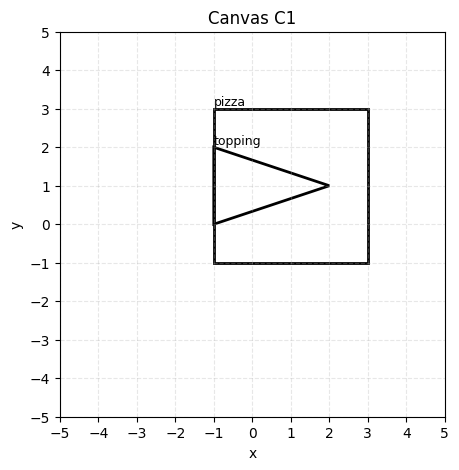

Plot saved as C1.png


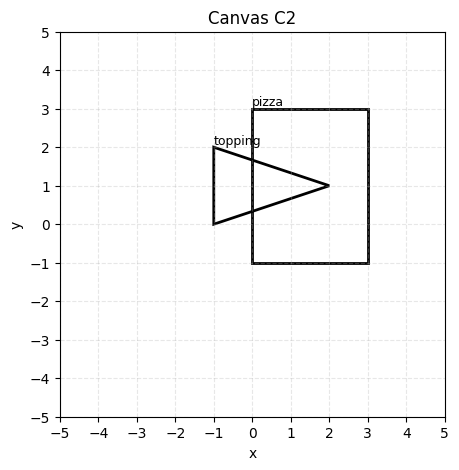

Plot saved as C2.png


In [20]:
plot_canvas(C1, bounds=(-5, 5, -5, 5), name="C1")
plot_canvas(C2, bounds=(-5, 5, -5, 5), name="C2")

# Normalize tuple changes in triangle

In [21]:
import re

def normalize_triangle_index_change(change_str: str) -> str:
    """
    Convert triangle point-index edits into whole-point assignments.

    Supported patterns:
    - obj.p1[0] = expr
    - obj.p1[1] = expr
    - obj.p2[0] += expr
    - obj.p2[1] -= expr
    - obj.p3[0] *= expr
    - obj.p3[1] /= expr

    Example:
    - 'topping.p3[1] = topping.p3[1] + 1'
      -> 'topping.p3 = (topping.p3[0], topping.p3[1] + 1)'

    - 'topping.p1[0] += 2'
      -> 'topping.p1 = (topping.p1[0] + 2, topping.p1[1])'
    """
    s = change_str.strip()

    # Match: object.point[index] op rhs
    # Example: topping.p3[1] = topping.p3[1] + 1
    pattern = r'^([A-Za-z_]\w*)\.(p[123])\[(0|1)\]\s*(=|\+=|-=|\*=|/=)\s*(.+)$'
    m = re.match(pattern, s)
    if not m:
        return s  # unchanged if not a triangle index edit

    obj, point, idx_str, op, rhs = m.groups()
    idx = int(idx_str)

    x_ref = f"{obj}.{point}[0]"
    y_ref = f"{obj}.{point}[1]"

    if op == "=":
        new_coord_expr = rhs.strip()
    else:
        # Convert +=, -=, *=, /= into explicit expression
        base = x_ref if idx == 0 else y_ref
        operator = op[0]  # +, -, *, /
        new_coord_expr = f"{base} {operator} ({rhs.strip()})"

    if idx == 0:
        return f"{obj}.{point} = ({new_coord_expr}, {y_ref})"
    else:
        return f"{obj}.{point} = ({x_ref}, {new_coord_expr})"

In [22]:
def normalize_change_group(change_group):
    """
    Normalize all change strings in a list.
    """
    normalized = []
    for ch in change_group:
        normalized.append(normalize_triangle_index_change(ch))
    return normalized

# Apply change to plot

In [23]:
import copy
from typing import List, Tuple, Dict, Any

def apply_json_change_and_plot(
    c2: List["NamedShape"],
    oracle_result: Dict[str, Any],
    intent_index: int,
    bounds: Tuple[float, float, float, float] = (-5, 5, -5, 5),
    name: str = "C2_changed",
    locked_properties: list = None,
    enforce_locked: bool = False,
    normalize_triangle_changes: bool = True
) -> List["NamedShape"]:
    """
    Copy C2, read one intent from an Oracle-style JSON result, apply all changes
    in that intent, optionally normalize triangle index edits, and plot the result.
    """
    updated = copy.deepcopy(c2)
    shape_lookup = {ns.name: ns.shape for ns in updated}

    if not isinstance(oracle_result, dict):
        raise TypeError("oracle_result must be a dictionary")

    intents = oracle_result.get("intents", [])
    if not isinstance(intents, list) or len(intents) == 0:
        raise ValueError("oracle_result must contain a non-empty 'intents' list")

    if intent_index < 0 or intent_index >= len(intents):
        raise IndexError(f"intent_index {intent_index} out of range for {len(intents)} intents")

    intent_item = intents[intent_index]
    intent = intent_item.get("intent", "")
    likelihood = intent_item.get("likelihood", None)
    next_items = intent_item.get("next", [])

    if not isinstance(next_items, list) or len(next_items) == 0:
        raise ValueError(f"Intent at index {intent_index} has no valid 'next' list")

    # Flatten all changes from next items
    change_group = []
    reason_group = []

    for nxt in next_items:
        changes = nxt.get("change", [])
        reason = nxt.get("reason", "")

        if isinstance(changes, str):
            changes = [changes]

        if not isinstance(changes, list):
            raise ValueError(f"'change' must be a string or list of strings in intent {intent_index}")

        for ch in changes:
            if not isinstance(ch, str):
                raise ValueError(f"Each change must be a string, got {type(ch)}")
            change_group.append(ch)

        if reason:
            reason_group.append(reason)

    if len(change_group) == 0:
        raise ValueError(f"No changes found in intent {intent_index}")

    # Normalize triangle changes if requested
    original_change_group = list(change_group)
    if normalize_triangle_changes:
        change_group = normalize_change_group(change_group)

    # Locked properties
    if locked_properties is None:
        locked_properties = oracle_result.get("locked_properties", [])

    locked_properties = locked_properties or []
    locked = {
        (item["object"], item["property"])
        for item in locked_properties
        if isinstance(item, dict) and "object" in item and "property" in item
    }

    def extract_lhs(change_str: str):
        for op in ["+=", "-=", "*=", "/=", "="]:
            if op in change_str:
                return change_str.split(op)[0].strip()
        return None

    # Check each change
    for change_str in change_group:
        lhs = extract_lhs(change_str)
        if lhs and "." in lhs:
            obj_name, prop_name = lhs.split(".", 1)
            base_prop_name = prop_name.split("[")[0]

            if (obj_name, prop_name) in locked or (obj_name, base_prop_name) in locked:
                msg = f"Change touches locked property: {obj_name}.{prop_name}"
                if enforce_locked:
                    raise ValueError(msg)
                print(f"Warning: {msg}")

    # Apply all changes sequentially
    safe_globals = {"__builtins__": {}}

    # --- ADDed ---
    class Canvas:
        pass

    canvas = Canvas()
    canvas.width = bounds[1] - bounds[0]
    canvas.height = bounds[3] - bounds[2]

    # (recommended small upgrade)
    canvas.xmin = bounds[0]
    canvas.ymin = bounds[2]

    # ----------------

    safe_locals = dict(shape_lookup)
    safe_locals["canvas"] = canvas #added

    applied_changes = []
    for change_str in change_group:
        try:
            exec(change_str, safe_globals, safe_locals)
            applied_changes.append(change_str)
        except Exception as e:
            raise ValueError(f"Failed to apply change '{change_str}': {e}")

    # Print summary
    print(f"Intent index: {intent_index}")
    print(f"Intent: {intent}")
    print(f"Likelihood: {likelihood}")
    print(f"Number of changes: {len(change_group)}")

    if reason_group:
        print("Reasons:")
        for r in reason_group:
            print(f"  - {r}")

    if normalize_triangle_changes:
        print("Original -> Applied changes:")
        for raw, norm in zip(original_change_group, change_group):
            print(f"  - {raw}")
            if raw != norm:
                print(f"    normalized to: {norm}")
    else:
        print("Applied changes:")
        for ch in change_group:
            print(f"  - {ch}")

    plot_canvas(updated, bounds=bounds, name=name)
    return updated

# llama results (Figure)

In [24]:
all_c3 = []
for i in range(len(oracle_result_llama["intents"])):
    try:
        c3 = apply_json_change_and_plot(
            c2=C2,
            oracle_result=oracle_result_llama,
            intent_index=i,
            name=f"C3_intent_llama_{i}",
            enforce_locked=False
        )
        all_c3.append(c3)
    except Exception as e:
        print(f"Intent {i} failed: {e}")

NameError: name 'oracle_result_llama' is not defined

# Visualize Helper Funcs

In [25]:
import copy
import json
import math
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as MplRect, Circle as MplCircle, Polygon
from typing import List, Tuple, Union, Dict, Any

In [26]:
def make_oracle_poster_figure_with_c3(
    C1: List[NamedShape],
    C2: List[NamedShape],
    result_dict: Dict[str, Any],
    bounds: Tuple[float, float, float, float] = (-5, 5, -5, 5),
    save_path: str = "oracle_poster_with_c3.png",
    enforce_locked: bool = False,
    enforce_single_object: bool = False
):
    df = oracle_output_to_dataframe(result_dict)
    c3_outputs = generate_all_c3s(
        c2=C2,
        result_dict=result_dict,
        enforce_locked=enforce_locked,
        enforce_single_object=enforce_single_object
    )

    n_intents = len(c3_outputs)
    ncols = 3
    nrows = 1 + math.ceil(n_intents / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    # C1 and C2
    draw_canvas_on_ax(axes[0], C1, bounds=bounds, title="C1: Before")
    draw_canvas_on_ax(axes[1], C2, bounds=bounds, title="C2: After User Edit")

    # likelihood chart
    ax_bar = axes[2]
    ax_bar.bar(df["rank"].astype(str), df["likelihood"])
    ax_bar.set_title("Intent Likelihoods")
    ax_bar.set_xlabel("Rank")
    ax_bar.set_ylabel("Likelihood")
    ax_bar.set_ylim(0, 1)
    for i, val in enumerate(df["likelihood"]):
        ax_bar.text(i, float(val) + 0.02, f"{val:.2f}", ha="center", fontsize=9)

    # C3s
    for idx, item in enumerate(c3_outputs):
        ax_idx = idx + 3
        if ax_idx >= len(axes):
            break

        ax = axes[ax_idx]
        if item["c3"] is None:
            ax.axis("off")
            ax.set_title(f"C3 rank {item['rank']}: ERROR")
            ax.text(0.02, 0.9, item["intent"], fontsize=10, transform=ax.transAxes)
            ax.text(0.02, 0.7, item["error"], fontsize=9, transform=ax.transAxes, wrap=True)
        else:
            draw_canvas_on_ax(
                ax,
                item["c3"],
                bounds=bounds,
                title=f"C3 rank {item['rank']} ({item['likelihood']:.2f})"
            )
            ax.text(
                0.02, 1.02,
                item["intent"],
                transform=ax.transAxes,
                fontsize=10
            )

    # hide unused axes
    for j in range(3 + n_intents, len(axes)):
        axes[j].axis("off")

    locked_text = ", ".join(
        [f"{x['object']}.{x['property']}" for x in result_dict.get("locked_properties", [])]
    )

    fig.suptitle(
        f"Oracle Predictions and Generated C3 Canvases\nLocked properties: {locked_text}",
        fontsize=14, y=0.99
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Poster figure saved to: {save_path}")
    return df, c3_outputs

In [27]:
def summarize_oracle_result_with_c3(
    C1: List[NamedShape],
    C2: List[NamedShape],
    result_dict: Dict[str, Any],
    bounds: Tuple[float, float, float, float] = (-5, 5, -5, 5),
    figure_path: str = "oracle_summary_with_c3.png",
    enforce_locked: bool = False,
    enforce_single_object: bool = False
):
    df, c3_outputs = make_oracle_poster_figure_with_c3(
        C1=C1,
        C2=C2,
        result_dict=result_dict,
        bounds=bounds,
        save_path=figure_path,
        enforce_locked=enforce_locked,
        enforce_single_object=enforce_single_object
    )
    return df, c3_outputs

# Execute (summary figs - error)

In [28]:
import math
import matplotlib.pyplot as plt

def make_poster_summary_figure(
    C1,
    C2,
    all_c3,
    oracle_result,
    bounds=(-5, 5, -5, 5),
    save_path=save_drive+"poster_summary_figure.png",
    figsize=(20, 10)
):
    """
    Create a poster-ready summary figure showing:
      - C1
      - C2
      - up to 5 predicted C3 canvases
      - likelihood bar chart + locked property summary

    Parameters
    ----------
    C1 : List[NamedShape]
        Original canvas before user edit.
    C2 : List[NamedShape]
        Canvas after user edit.
    all_c3 : list
        List of predicted canvases already generated from apply_json_change_and_plot.
        Should align with oracle_result["intents"] order.
    oracle_result : dict
        Oracle JSON result with "locked_properties" and "intents".
    bounds : tuple
        Plot bounds.
    save_path : str
        Output image file path.
    figsize : tuple
        Figure size.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    intents = oracle_result.get("intents", [])
    locked_properties = oracle_result.get("locked_properties", [])

    fig, axes = plt.subplots(2, 4, figsize=figsize)
    axes = axes.flatten()

    # Panel 1: C1
    draw_canvas_on_ax(axes[0], C1, bounds=bounds, title="C1: Before Edit")

    # Panel 2: C2
    draw_canvas_on_ax(axes[1], C2, bounds=bounds, title="C2: After Edit")

    # Panels 3~7: up to five C3 predictions
    max_preds = min(5, len(all_c3), len(intents))
    for i in range(max_preds):
        title = f"Pred {i+1}: {intents[i].get('intent', '')}\n(p={intents[i].get('likelihood', 0):.2f})"
        draw_canvas_on_ax(axes[i + 2], all_c3[i], bounds=bounds, title=title)

    # Hide unused prediction axes if fewer than 5
    for j in range(2 + max_preds, 7):
        axes[j].axis("off")

    # Panel 8: likelihood bar chart + locked properties
    ax_bar = axes[7]
    likelihoods = [item.get("likelihood", 0.0) for item in intents[:5]]
    labels = [str(i + 1) for i in range(len(likelihoods))]

    ax_bar.bar(labels, likelihoods)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_xlabel("Prediction Rank")
    ax_bar.set_ylabel("Likelihood")
    ax_bar.set_title("Intent Ranking")

    for i, val in enumerate(likelihoods):
        ax_bar.text(i, val + 0.03, f"{val:.2f}", ha="center", fontsize=10)

    locked_text = ", ".join(
        [f"{lp['object']}.{lp['property']}" for lp in locked_properties]
    ) if locked_properties else "None"

    ax_bar.text(
        0.02, -0.28,
        f"Locked properties: {locked_text}",
        transform=ax_bar.transAxes,
        fontsize=10,
        va="top"
    )

    fig.suptitle(
        "Intent-Aware Ranking of Candidate Design Actions",
        fontsize=18,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Poster summary figure saved to: {save_path}")
    return fig

In [29]:
# make_poster_summary_figure(
#     C1=C1,
#     C2=C2,
#     all_c3=all_c3,
#     oracle_result=oracle_result_llama,
#     bounds=(-5, 5, -5, 5),
#     save_path="poster_summary_figure.png"
# )

NameError: name 'oracle_result_llama' is not defined

# Mistral 7B

In [ ]:
#pip install mistral_inference

In [30]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "mistralai/Mistral-7B-Instruct-v0.3"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype="auto"
)

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

In [ ]:
@torch.inference_mode()
def predict_next_item_debug_mistral(
    c1,
    c2,
    tokenizer,
    model,
    max_new_tokens=900,
    do_sample=False
):
    # Set pad token BEFORE tokenization
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    user_prompt = build_prompt(c1, c2)

    # Mistral prompt format
    prompt = f"<s>[INST] {user_prompt} [/INST]"

    # Tokenize WITH attention mask
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(model.device)

    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    generation_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        pad_token_id=tokenizer.pad_token_id
    )

    if do_sample:
        generation_kwargs["temperature"] = 0.2
        generation_kwargs["top_p"] = 0.9

    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        **generation_kwargs
    )

    generated = outputs[0][input_ids.shape[-1]:]
    raw_text = tokenizer.decode(generated, skip_special_tokens=True)

    json_str = None
    parsed = None
    error = None

    try:
        json_str = extract_first_json_object(raw_text)
        parsed = json.loads(json_str)
    except Exception as e:
        error = str(e)

    return {
        "prompt": prompt,
        "raw_output": raw_text,
        "json_str": json_str,
        "parsed": parsed,
        "error": error
    }

In [ ]:
# result_mistral = predict_next_item_debug_mistral(
#     c1=C1,
#     c2=C2,
#     tokenizer=tokenizer,
#     model=model,
#     max_new_tokens=256,
#     do_sample=False
# )

In [ ]:
result_mistral = predict_next_item_debug_mistral(
    c1=C1,
    c2=C2,
    tokenizer=tokenizer,
    model=model,
    max_new_tokens=900,
    do_sample=True
)

In [ ]:
# print(result["raw_output"])
# print(result["error"])
oracle_res_mistral = result_mistral["parsed"]

In [31]:
def save_display(model_name, res, i):
  with open(save_drive + model_name+f"_textual{i}.json", 'w') as f:
    json.dump(res, f)

  with open(save_drive + model_name+f"_textual{i}.json", "r") as f:
    data = json.load(f)   # try this first
  df = json_to_df_simple(data)
  display(df)

In [ ]:
save_display("mistral", oracle_res_mistral,"_revised")

In [ ]:
all_c3 = []
for i in range(len(oracle_res_mistral["intents"])):
    try:
        c3 = apply_json_change_and_plot(
            c2=C2,
            oracle_result=oracle_res_mistral,
            intent_index=i,
            name=f"C3_intent_mistral_{i}",
            enforce_locked=False
        )
        all_c3.append(c3)
    except Exception as e:
        print(f"Intent {i} failed: {e}")

In [ ]:
result_mistral_3 = predict_next_item_debug_mistral(
    c1=C1,
    c2=C2,
    tokenizer=tokenizer,
    model=model,
    max_new_tokens=900,
    do_sample=True
)
save_display("mistral", result_mistral_3["parsed"], 3)

In [71]:
# with open(save_drive +"Molmo_multimodal2.json", "w") as f:
#     json.dump({
#   "locked_properties": [
#     {"object": "rect", "property": "y"},
#     {"object": "rect", "property": "w"},
#     {"object": "rect", "property": "h"},
#     {"object": "triangle", "property": "p1"},
#     {"object": "triangle", "property": "p2"},
#     {"object": "triangle", "property": "p3"},
#     {"object": "text", "property": "text"}
#   ],
#   "intents": [
#     {
#       "intent": "move pizza rectangle",
#       "likelihood": 0.8,
#       "next": [
#         {
#           "change": ["rect.x = 0", "rect.w = 3"],
#           "reason": "move pizza rectangle to new position"
#         }
#       ]
#     },
#     {
#       "intent": "move topping triangle",
#       "likelihood": 0.7,
#       "next": [
#         {
#           "change": ["triangle.p1.x = 1", "triangle.p1.y = 1", "triangle.p2.x = 2", "triangle.p2.y = 1", "triangle.p3.x = 2", "triangle.p3.y = 2"],
#           "reason": "move topping triangle to new position"
#         }
#       ]
#     },
#     {
#       "intent": "move pizza text",
#       "likelihood": 0.6,
#       "next": [
#         {
#           "change": ["text.x = 2", "text.y = 2"],
#           "reason": "move pizza text to new position"
#         }
#       ]
#     },
#     {
#       "intent": "move topping text",
#       "likelihood": 0.5,
#       "next": [
#         {
#           "change": ["text.x = 2", "text.y = 2"],
#           "reason": "move topping text to new position"
#         }
#       ]
#     },
#     {
#       "intent": "resize pizza rectangle",
#       "likelihood": 0.4,
#       "next": [
#         {
#           "change": ["rect.w = 3", "rect.h = 4"],
#           "reason": "resize pizza rectangle"
#         }
#       ]
#     }
#   ]
# }
# , f)
# display(json_to_df_simple(data))

with open(save_drive +"Molmo_multimodal2.json", "r") as f:
    data = json.load(f)   # try this first
display(json_to_df_simple(data))

,rank,intent,likelihood,change,reason
0,1,move pizza rectangle,0.8,"[rect.x = 0, rect.w = 3]",move pizza rectangle to new position
1,2,move topping triangle,0.7,"[triangle.p1.x = 1, triangle.p1.y = 1, triangl...",move topping triangle to new position
2,3,move pizza text,0.6,"[text.x = 2, text.y = 2]",move pizza text to new position
3,4,move topping text,0.5,"[text.x = 2, text.y = 2]",move topping text to new position
4,5,resize pizza rectangle,0.4,"[rect.w = 3, rect.h = 4]",resize pizza rectangle


# Llava

In [32]:
from transformers import LlavaProcessor, LlavaForConditionalGeneration

In [33]:
from transformers import LlavaProcessor, LlavaForConditionalGeneration
from PIL import Image

model_id = "llava-hf/llava-1.5-7b-hf"

processor = LlavaProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype="auto"
)

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [34]:
#!pip -q install accelerate

In [35]:
import os
import json
import torch
from PIL import Image, ImageDraw
from transformers import AutoProcessor, LlavaForConditionalGeneration

In [36]:
MODEL_ID = "llava-hf/llava-1.5-7b-hf"

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

LlavaForConditionalGeneration(
  (model): LlavaModel(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
       

In [37]:
save_drive = '/content/drive/MyDrive/Smith/BVC/'

In [38]:
def make_side_by_side_image(
    left_path: str,
    right_path: str,
    out_path: str = save_drive+"C1_C2_pair.png"
):
    left = Image.open(save_drive+left_path).convert("RGB")
    right = Image.open(save_drive+right_path).convert("RGB")

    width = left.width + right.width
    height = max(left.height, right.height)

    canvas = Image.new("RGB", (width, height), "white")
    canvas.paste(left, (0, 0))
    canvas.paste(right, (left.width, 0))

    draw = ImageDraw.Draw(canvas)
    draw.text((10, 10), "C1", fill="black")
    draw.text((left.width + 10, 10), "C2", fill="black")

    canvas.save(save_drive+out_path)
    return out_path

In [64]:
def build_llava_prompt():
    return """Return valid JSON only.

This image contains two canvases side by side:
- left: C1 (before)
- right: C2 (after one user edit)

C1 = [
    NamedShape("pizza", Rect(-1.0, 3.0, 4.0, 4.0)),
    NamedShape(
        "topping",
        Triangle(
            (-1.0, 0.0),
            (2.0, 1.0),
            (-1.0, 2.0)
        )
    ),
]

C2 = [
    NamedShape("pizza", Rect(0.0, 3.0, 3.0, 4.0)),
    NamedShape(
        "topping",
        Triangle(
            (-1.0, 0.0),
            (2.0, 1.0),
            (-1.0, 2.0)
        )
    ),
]


Shape properties:
- Rect: x, y, w, h
- Circle: cx, cy, r
- Triangle: p1, p2, p3

Tasks:
1. Find all changed object-property pairs from C1 to C2.
2. Put them in "locked_properties".
3. Infer up to 5 intents.
4. For each intent, predict next change(s) without modifying locked properties. Provide the most probable expression as number or equation.

Rules:
- Use only objects and properties visible in the canvases.
- Each intent modifies ONE object only.
- Multiple properties may be changed only for translation of the same object.
- Do not modify multiple objects in one intent.
- "change" must be a list of equation strings.
- No natural language inside equations.
- Output JSON only. No markdown. No extra text.

Schema:
{
  "locked_properties": [
    {"object": "...", "property": "..."}
  ],
  "intents": [
    {
      "intent": "...",
      "likelihood": 0.0,
      "next": [
        {
          "change": ["object.property = expression"],
          "reason": "..."
        }
      ]
    }
  ]
}
"""

In [65]:
@torch.inference_mode()
def predict_with_llava_single_image(
    image_path: str,
    processor,
    model,
    max_new_tokens: int = 900
):
    image = Image.open(save_drive+image_path).convert("RGB")
    prompt = build_llava_prompt()

    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        },
    ]

    # Step 1: make formatted text prompt only
    text_prompt = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True
    )

    # Step 2: process text + image TOGETHER
    inputs = processor(
        text=text_prompt,
        images=image,
        return_tensors="pt"
    )

    # Explicitly pass text="" to avoid NoneType error
    image_inputs = processor(text="", images=image, return_tensors="pt")
    inputs["pixel_values"] = image_inputs["pixel_values"]

    # Step 3: move to model device
    inputs = {
        k: (
            v.to(model.device, dtype=torch.float16)
            if torch.is_tensor(v) and v.dtype.is_floating_point
            else v.to(model.device)
            if torch.is_tensor(v)
            else v
        )
        for k, v in inputs.items()
    }

    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    output_text = processor.decode(generated_ids, skip_special_tokens=True)

    return output_text

In [62]:
pair_path = make_side_by_side_image("C1.png", "C2.png", "C1_C2_pair.png")

In [66]:

# Step 3: run LLaVA
raw_output = predict_with_llava_single_image(
    image_path=pair_path,
    processor=processor,
    model=model,
    max_new_tokens=900
)

print("=== RAW OUTPUT ===")
print(raw_output)

=== RAW OUTPUT ===
{
"locked\_properties": [
{"object": "pizza", "property": "x"},
{"object": "topping", "property": "x"}
],
"intents": [
{
"intent": "move\_pizza",
"likelihood": 0.3,
"next": [
{
"change": ["object.property = expression"],
"reason": "Move pizza to new location"
}
]
},
{
"intent": "move\_topping",
"likelihood": 0.3,
"next": [
{
"change": ["object.property = expression"],
"reason": "Move topping to new location"
}
]
},
{
"intent": "change\_size",
"likelihood": 0.3,
"next": [
{
"change": ["object.property = expression"],
"reason": "Change size of pizza or topping"
}
]
},
{
"intent": "change\_shape",
"likelihood": 0.3,
"next": [
{
"change": ["object.property = expression"],
"reason": "Change shape of pizza or topping"
}
]
},
{
"intent": "change\_color",
"likelihood": 0.3,
"next": [
{
"change": ["object.property = expression"],
"reason": "Change color of pizza or topping"
}
]
}
}


In [43]:
@torch.inference_mode()
def predict_with_llava_single_image(
    image_path: str,
    processor,
    model,
    max_new_tokens: int = 300
):
    image = Image.open(save_drive + image_path).convert("RGB")

    prompt = """USER: <image>
Compare the left and right canvas.
The left canvas is C1 before the edit.
The right canvas is C2 after the edit.
Which object changed? Describe the change in one sentence.
ASSISTANT:"""

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: (
            v.to(model.device, dtype=torch.float16)
            if torch.is_tensor(v) and v.dtype.is_floating_point
            else v.to(model.device)
            if torch.is_tensor(v)
            else v
        )
        for k, v in inputs.items()
    }

    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    output_text = processor.decode(generated_ids, skip_special_tokens=True)

    return output_text

In [44]:
raw_output = predict_with_llava_single_image(
    image_path=pair_path,
    processor=processor,
    model=model,
    max_new_tokens=120
)

print(raw_output)

The pizza on the left canvas is topped with cheese, while the pizza on the right canvas is topped with pepperoni.


In [45]:
@torch.inference_mode()
def predict_with_llava_single_image(
    image_path: str,
    processor,
    model,
    max_new_tokens: int = 300
):
    image = Image.open(save_drive + image_path).convert("RGB")

    prompt = """USER: <image>
This image contains two canvases side by side:
left = C1 before edit, right = C2 after edit.

Return valid JSON only.

Find the changed object-property pairs and infer up to 5 next intents.

Schema:
{
  "locked_properties": [
    {"object": "...", "property": "..."}
  ],
  "intents": [
    {
      "intent": "...",
      "likelihood": 0.0,
      "next": [
        {
          "change": ["object.property = expression"],
          "reason": "..."
        }
      ]
    }
  ]
}
ASSISTANT:"""

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: (
            v.to(model.device, dtype=torch.float16)
            if torch.is_tensor(v) and v.dtype.is_floating_point
            else v.to(model.device)
            if torch.is_tensor(v)
            else v
        )
        for k, v in inputs.items()
    }

    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    output_text = processor.decode(generated_ids, skip_special_tokens=True)

    return output_text

raw_output = predict_with_llava_single_image(
    image_path=pair_path,
    processor=processor,
    model=model,
    max_new_tokens=120
)

print(raw_output)

{
"locked\_properties": [
{"object": "canvas", "property": "x"}
],
"intents": [
{
"intent": "move\_canvas",
"likelihood": 0.0,
"next": [
{
"change": ["object.property = expression"],
"reason": "Move the canvas to a new position."
}
]
},
{
"intent": "rotate\_canvas",
"likelihood": 0.0,
"next": [
{
"change": ["


# Molmo 8b Trial

In [46]:
with open(save_drive + "Molmo_multimodal.json", "r") as f:
    data = json.load(f)   # try this first
df = json_to_df_simple(data)
display(df)

,rank,intent,likelihood,change,reason
0,1,move pizza rectangle,0.8,"[rect.y = 2, rect.x = 1]",move pizza rectangle to new position
1,2,move topping triangle,0.7,"[triangle.p1.x = 1, triangle.p1.y = 1, triangl...",move topping triangle to new position
2,3,move pizza text,0.6,"[text.x = 2, text.y = 2]",move pizza text to new position
3,4,move topping text,0.5,"[text.x = 2, text.y = 2]",move topping text to new position
4,5,resize pizza rectangle,0.4,"[rect.w = 2, rect.h = 2]",resize pizza rectangle


In [48]:
print(data)

{'locked_properties': [{'object': 'rect', 'property': 'x'}, {'object': 'rect', 'property': 'y'}, {'object': 'rect', 'property': 'w'}, {'object': 'rect', 'property': 'h'}, {'object': 'triangle', 'property': 'p1'}, {'object': 'triangle', 'property': 'p2'}, {'object': 'triangle', 'property': 'p3'}, {'object': 'text', 'property': 'text'}], 'intents': [{'intent': 'move pizza rectangle', 'likelihood': 0.8, 'next': [{'change': ['rect.y = 2', 'rect.x = 1'], 'reason': 'move pizza rectangle to new position'}]}, {'intent': 'move topping triangle', 'likelihood': 0.7, 'next': [{'change': ['triangle.p1.x = 1', 'triangle.p1.y = 1', 'triangle.p2.x = 2', 'triangle.p2.y = 1', 'triangle.p3.x = 2', 'triangle.p3.y = 2'], 'reason': 'move topping triangle to new position'}]}, {'intent': 'move pizza text', 'likelihood': 0.6, 'next': [{'change': ['text.x = 2', 'text.y = 2'], 'reason': 'move pizza text to new position'}]}, {'intent': 'move topping text', 'likelihood': 0.5, 'next': [{'change': ['text.x = 2', 'te

In [47]:
all_c3 = []
for i in range(len(data["intents"])):
    try:
        c3 = apply_json_change_and_plot(
            c2=C2,
            oracle_result=data,
            intent_index=i,
            name=f"C3_intent_mistral_{i}",
            enforce_locked=False
        )
        all_c3.append(c3)
    except Exception as e:
        print(f"Intent {i} failed: {e}")

Intent 0 failed: Failed to apply change 'rect.y = 2': name 'rect' is not defined
Intent 1 failed: Failed to apply change 'triangle.p1.x = 1': name 'triangle' is not defined
Intent 2 failed: Failed to apply change 'text.x = 2': name 'text' is not defined
Intent 3 failed: Failed to apply change 'text.x = 2': name 'text' is not defined
Intent 4 failed: Failed to apply change 'rect.w = 2': name 'rect' is not defined


In [49]:
!pip -q install transformers==4.57.1 torch pillow einops torchvision accelerate molmo_utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 14.4 MB/s eta 0:00:00


In [50]:
import json
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "allenai/Molmo2-8B"

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    dtype="auto",
    device_map="auto",
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    dtype="auto",
    device_map="auto",
)

model.eval()

processor_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

processing_molmo2.py: 0.00B [00:00, ?B/s]

image_processing_molmo2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/allenai/Molmo2-8B:
- image_processing_molmo2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.5M [00:00<?, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

TypeError: Unexpected keyword argument image_use_col_tokens.

In [51]:
import transformers
print(transformers.__version__)

5.0.0


In [52]:
def build_molmo_prompt():
    return """Compare the two canvas images.

Image 1 is C1 before edit.
Image 2 is C2 after one edit.
The texts in the images are not a part of canvas objects.

Return valid JSON only.

Tasks:
1. Find all changed object-property pairs from C1 to C2.
2. Put them in locked_properties.
3. Infer up to 5 possible next intents.
4. For each intent, predict next change(s) without modifying locked properties.

Rules:
- Use only visible object names and valid shape properties.
- Rect properties: x, y, w, h.
- Circle properties: cx, cy, r.
- Triangle properties: p1, p2, p3.
- Each intent modifies ONE object only.
- change must be a list of equation strings.
- No natural language inside equations.
- No markdown or extra text.

Schema:
{
  "locked_properties": [
    {"object": "...", "property": "..."}
  ],
  "intents": [
    {
      "intent": "...",
      "likelihood": 0.0,
      "next": [
        {
          "change": ["object.property = expression"],
          "reason": "..."
        }
      ]
    }
  ]
}
"""

In [54]:
@torch.inference_mode()
def predict_with_molmo_two_images(
    c1_image_path: str,
    c2_image_path: str,
    processor,
    model,
    max_new_tokens: int = 448,
):
    image1 = Image.open(c1_image_path).convert("RGB")
    image2 = Image.open(c2_image_path).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                dict(type="text", text=build_molmo_prompt()),
                dict(type="image", image=image1),
                dict(type="image", image=image2),
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )

    generated_tokens = generated_ids[0, inputs["input_ids"].size(1):]
    generated_text = processor.tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True,
    )

    return generated_text

In [55]:
def extract_first_json_object(text: str) -> str:
    start = text.find("{")
    if start == -1:
        raise ValueError("No JSON object found.")

    depth = 0
    for i in range(start, len(text)):
        if text[i] == "{":
            depth += 1
        elif text[i] == "}":
            depth -= 1
            if depth == 0:
                return text[start:i + 1]

    raise ValueError("Incomplete JSON object.")

In [59]:
# plot_canvas(C1, bounds=(-5, 5, -5, 5), name="C1")
# plot_canvas(C2, bounds=(-5, 5, -5, 5), name="C2")

raw_output = predict_with_molmo_two_images(
    c1_image_path=save_drive+"C1.png",
    c2_image_path=save_drive+"C2.png",
    processor=processor,
    model=model,
    max_new_tokens=2000,
)

print("=== RAW OUTPUT ===")
print(raw_output)

# json_str = extract_first_json_object(raw_output)
# oracle_result_molmo = json.loads(json_str)

# print("=== PARSED JSON ===")
# print(json.dumps(oracle_result_molmo, indent=2))

=== RAW OUTPUT ===
{
"locked\_properties": [
{"object": "canvas", "property": "x"},
{"object": "canvas", "property": "y"},
{"object": "canvas", "property": "w"},
{"object": "canvas", "property": "h"},
{"object": "canvas", "property": "cx"},
{"object": "canvas", "property": "cy"},
{"object": "canvas", "property": "r"}
],
"intents": [
{
"intent": "rotate",
"likelihood": 0.0,
"next": [
{
"change": ["object.property = expression"],
"reason": "rotate canvas by 10 degrees"
}
]
},
{
"intent": "scale",
"likelihood": 0.0,
"next": [
{
"change": ["object.property = expression"],
"reason": "scale canvas by 1.2"
}
]
},
{
"intent": "move",
"likelihood": 0.0,
"next": [
{
"change": ["object.property = expression"],
"reason": "move canvas to (10, 10)"
}
]
},
{
"intent": "rotate",
"likelihood": 0.0,
"next": [
{
"change": ["object.property = expression"],
"reason": "rotate canvas by 20 degrees"
}
]
},
{
"intent": "scale",
"likelihood": 0.0,
"next": [
{
"change": ["object.property = expression"],
"reason"